In [1]:
here::i_am("01_create_arrow.R")
source(here::here("settings.R"))
source(here::here("load_archr.R"))
library(viridis)

addArchRThreads(16)

here() starts at /rds/project/rds-SDzz0CATGms/users/bt392/04_rabbit_scATAC/code

Setting default number of Parallel threads to 1.

Setting addArchRVerbose = FALSE

Successfully loaded ArchRProject!


                                                   / |
                                                 /    \
            .                                  /      |.
            \\\                              /        |.
              \\\                          /           `|.
                \\\                      /              |.
                  \                    /                |\
                  \\#####\           /                  ||
                ==###########>      /                   ||
                 \\##==......\    /                     ||
            ______ =       =|__ /__                     ||      \\\
        ,--' ,----`-,__ ___/'  --,-`-===================##========>
       \               '        ##_______ _____ ,--,__,=##,__   ///
        ,    __==

# Subset

In [2]:
meta = ArchRProject@cellColData
unique(meta$predictedGroup_celltype_PeakMatrix)

[1] "Hypoblast"                       "Haematoendothelial progenitors" 
 [3] "Nascent mesoderm"                "Epiblast"                       
 [5] "Trophoblast"                     "Visceral endoderm"              
 [7] "Primitive Streak"                "Parietal YS endoderm"           
 [9] "Definitive Endoderm"             "Allantois endothelium"          
[11] "Embryo proper endothelium"       "EMP"                            
[13] "Anterior Primitive Streak"       "Notochord"                      
[15] "PGC"                             "Venous endothelium"             
[17] "NMPs"                            "Syncytiotrophoblast"            
[19] "Hindbrain"                       "Cytotrophoblast"                
[21] "Lateral plate mesoderm"          "Cranial mesoderm"               
[23] "Syncytiotrophoblast progenitors" "Presomitic mesoderm"            
[25] "NMPs/Mesoderm-biased"            "Mesenchyme"                     
[27] "Gut endoderm"                    "Cardiomyocytes FHF 2"           
[29] "Pharyngeal endoderm"             "Amnion 1"                       
[31] "Erythroid"                       "Dermomyotome"                   
[33] "Somitic mesoderm"                "Amnion 2"                       
[35] "Cardiomyocytes FHF 1"            "MEP"                            
[37] "Caudal mesoderm"                 "Visceral YS endoderm"           
[39] "Cardiopharyngeal progenitors"    "YS endothelium"                 
[41] "Mesothelium"                     "Visceral YS endoderm 2"         
[43] "Megakariocytes"                  "Migratory neural crest"         
[45] "Cranial neural crest"            "Floor plate"                    
[47] "Spinal cord"                     "Forebrain"                      
[49] "Nephron progenitors"             "Midbrain"                       
[51] "Allantois"                       "Limb mesoderm"                  
[53] "Epicardium"                      "Non-neural ectoderm 2"          
[55] "Differentiating neurons"         "Sclerotome"                     
[57] "Posterior somitic tissues"       "Placodal ectoderm"              
[59] "Non-neural ectoderm 4"           "Gut tube"

In [5]:
rm_celltypes = c('Hypoblast','Visceral endoderm','Parietal YS endoderm','Visceral YS endoderm','Visceral YS endoderm 2', # hypoblast
                'Trophoblast','Syncytiotrophoblast','Cytotrophoblast','Syncytiotrophoblast progenitors', # trohpoblast
                'Amnion 1','Amnion 2', 'Amnion 3') # Amnion

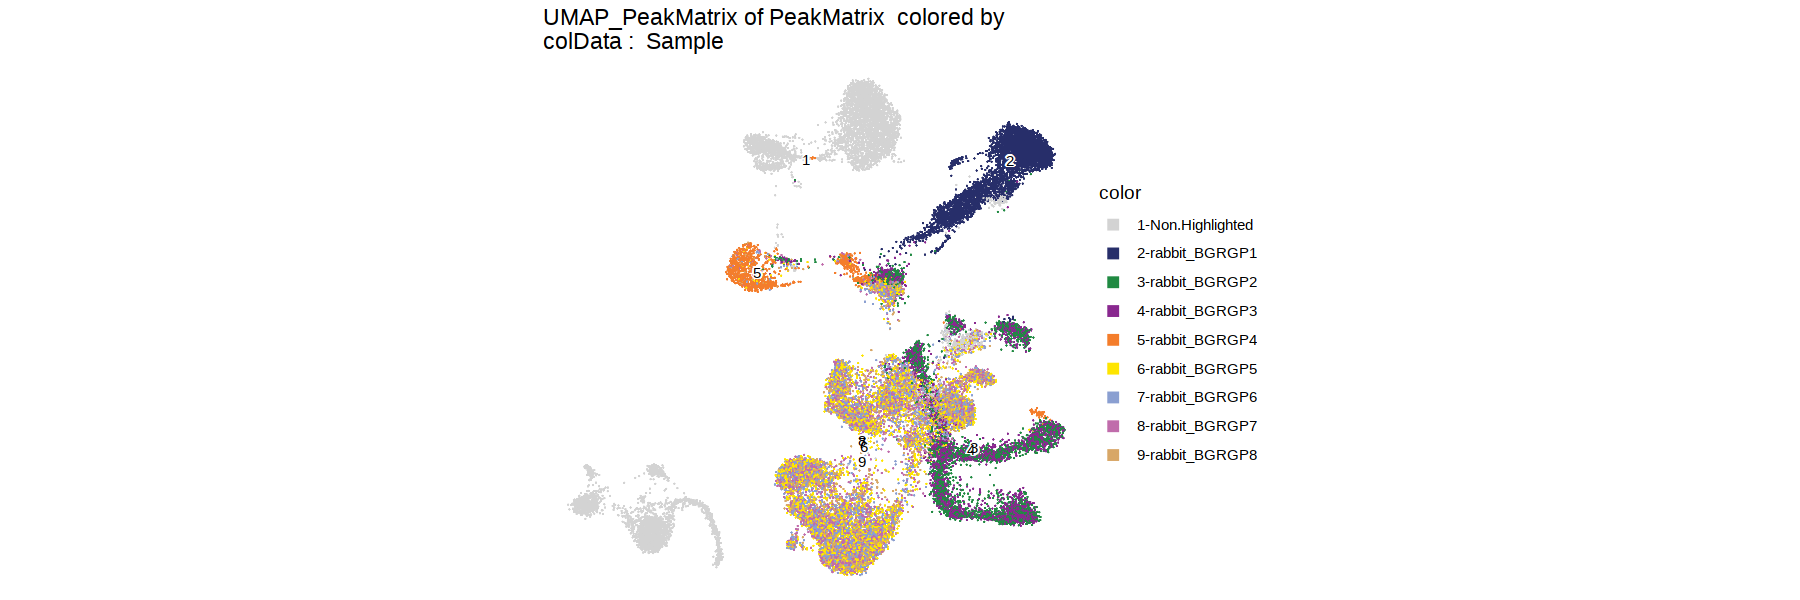

In [6]:
keep_cells = meta[!meta$predictedGroup_celltype_PeakMatrix %in% rm_celltypes, 'cell']
plotEmbedding(
  ArchRProj = ArchRProject,
  embedding = "UMAP_PeakMatrix",
  highlightCells = keep_cells) + theme_void()

# Select cells

In [8]:
ArchRProject = subsetArchRProject(
  ArchRProj = ArchRProject,
  cells = keep_cells,
  outputDirectory = "Embryo_proper",
  dropCells = TRUE,
  logFile = NULL,
  threads = getArchRThreads(),
  force = TRUE
)

Dropping ImputeWeights Since You Are Subsetting Cells! ImputeWeights is a cell-x-cell Matrix!

Copying ArchRProject to new outputDirectory : /rds/project/rds-SDzz0CATGms/users/bt392/04_rabbit_scATAC/ArchR/Embryo_proper

Copying Arrow Files...

Getting ImputeWeights

No imputeWeights found, returning NULL

Copying Other Files...

Copying Other Files (1 of 14): Annotations

Copying Other Files (2 of 14): Background-Peaks.rds

Copying Other Files (3 of 14): Embeddings

Copying Other Files (4 of 14): GeneScoreMatrix.rds

Copying Other Files (5 of 14): genome

Copying Other Files (6 of 14): GroupBigWigs

Copying Other Files (7 of 14): GroupCoverages

Copying Other Files (8 of 14): IterativeLSI

Copying Other Files (9 of 14): Monocole3

Copying Other Files (10 of 14): PeakCalls

Copying Other Files (11 of 14): PeakMatrix

Copying Other Files (12 of 14): Plots

Copying Other Files (13 of 14): RNAIntegration

Copying Other Files (14 of 14): TileMatrix

Saving ArchRProject...

Loading ArchRProj

# Load Embryo proper data

In [1]:
source(here::here("settings.R"))
ArchRProject <- loadArchRProject(file.path(io$basedir, 'ArchR/Embryo_proper'))
library(viridis)

# I/O
io$plot = file.path(io$basedir, 'ArchR/Embryo_proper/plots')
dir.create(io$plot, showWarnings = FALSE)


Setting default number of Parallel threads to 1.

Setting addArchRVerbose = FALSE

Successfully loaded ArchRProject!


                                                   / |
                                                 /    \
            .                                  /      |.
            \\\                              /        |.
              \\\                          /           `|.
                \\\                      /              |.
                  \                    /                |\
                  \\#####\           /                  ||
                ==###########>      /                   ||
                 \\##==......\    /                     ||
            ______ =       =|__ /__                     ||      \\\
        ,--' ,----`-,__ ___/'  --,-`-===================##========>
       \               '        ##_______ _____ ,--,__,=##,__   ///
        ,    __==    ___,-,__,--'#'  ==='      `-'    | ##,-/
        -,____,---'       \\####\\__

In [11]:
dim_redu = function(matrix='PeakMatrix', ndims=20, nfeatures=25000, n_neighbors=25,min_dist=0.7 ){
    seed = 42

    # Options
    opts = list()
    opts$lsi.iterations = 2
    opts$lsi.cluster.resolution = 0.5

    ###########################
    ## Latent Semantic Index ##
    ###########################

    # Iterative LSI: two iterations
    ArchRProject <- addIterativeLSI(
      ArchRProj = ArchRProject,
      useMatrix = matrix, 
      name = paste0(matrix, '_EP'), 
      dimsToUse = 1:ndims,
      firstSelection = "Top",
      depthCol = "nFrags",
      iterations = opts$lsi.iterations, 
      saveIterations = FALSE,
      varFeatures = nfeatures, 
      force = TRUE
    )

    #Add clusters
    ArchRProject <- addClusters(input = ArchRProject,  
                             reducedDims = paste0(matrix, '_EP'),
                             resolution = opts$lsi.cluster.resolution, 
                             force=TRUE)

    ArchRProject <- addUMAP(
      ArchRProj = ArchRProject, 
      reducedDims = paste0(matrix, '_EP'),
      name = paste0("UMAP_EP_", matrix),
      metric = "cosine",
      nNeighbors = n_neighbors, 
      minDist = min_dist, 
      seed = seed,
      saveModel = FALSE,
      force = TRUE)

    p =  plotEmbedding(ArchRProject, 
        embedding=paste0("UMAP_EP_", matrix),
        colorBy = "cellColData", 
        name = "celltype_v1")+ theme_void() + theme(plot.margin=grid::unit(c(0,0,0,0), "mm"))
    print(p)
      #  return(ArchRProject)
}

Warning message:
“package ‘Seurat’ was built under R version 4.1.2”


Modularity Optimizer version 1.3.0 by Ludo Waltman and Nees Jan van Eck

Number of nodes: 26699
Number of edges: 1103126

Running Louvain algorithm...
Maximum modularity in 10 random starts: 0.9397
Number of communities: 20
Elapsed time: 3 seconds


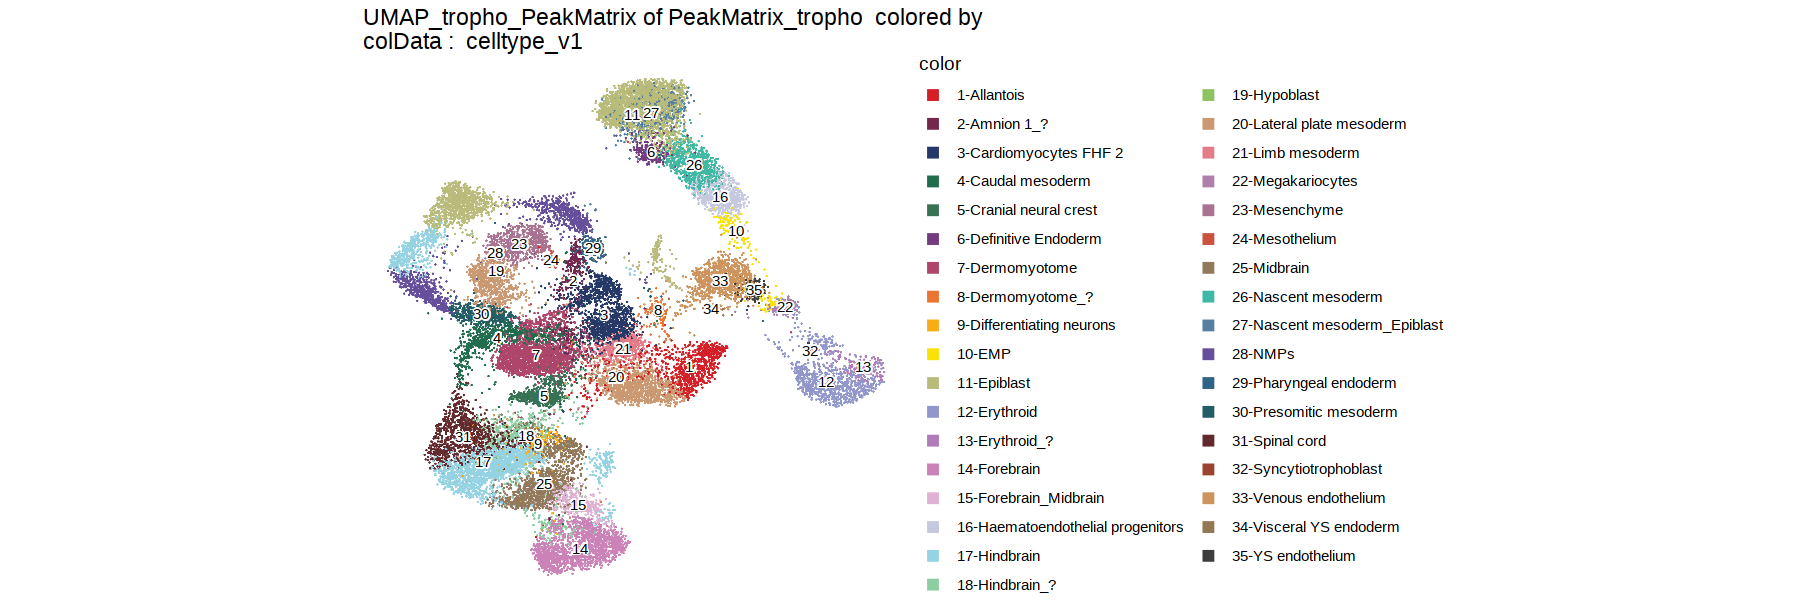

In [12]:
suppressMessages(dim_redu(ndims=35, nfeatures=65000))

# Gene Markers per cluster

using modified GTF from Dan

In [5]:
addArchRThreads(16)
library(stringr)

Setting default number of Parallel threads to 16.



In [6]:
gtf = fread('/rds/project/rds-SDzz0CATGms/users/bt392/04_rabbit_scATAC/genome/extension_plus_alignments.gtf') %>% 
    .[,c(1,3,4,5,7,9)] %>%
    setnames(c('seqnames', 'type', 'start','end','strand','info')) %>%
    .[,seqnames:=paste0('chr', seqnames)] %>% 
    .[seqnames %in% unique(seqnames(ArchRProject@genomeAnnotation$chromSizes))] %>%  # only keep the ones on mapped chrs
    .[type %in% c('gene', 'exon')] %>%
    .[grep('gene_name',info)] %>% # only keep genes with a name
    .[,`:=`(gene_id = str_split(info, ';') %>% map_chr(1) %>% gsub('gene_id','',.) %>% gsub('"','',.) %>% gsub(' ','',.),
            symbol = str_split(info, 'gene_name') %>% map_chr(2) %>% str_split(., ';') %>% map_chr(1) %>% gsub('gene_id','',.) %>% gsub('"','',.) %>% gsub(' ','',.))]

Warning message in fread("/rds/project/rds-SDzz0CATGms/users/bt392/04_rabbit_scATAC/genome/extension_plus_alignments.gtf"):
“Detected 1 column names but the data has 9 columns (i.e. invalid file). Added 8 extra default column names at the end.”


In [7]:
head(gtf)

seqnames,type,start,end,strand,info,gene_id,symbol
<chr>,<chr>,<int>,<int>,<chr>,<chr>,<chr>,<chr>
chr1,gene,15188,30378,+,"gene_id ""ENSOCUG00000014251""; gene_version ""3""; gene_name ""WDR31""; gene_source ""ensembl""; gene_biotype ""protein_coding"";",ENSOCUG00000014251,WDR31
chr1,exon,15188,15281,+,"gene_id ""ENSOCUG00000014251""; gene_version ""3""; transcript_id ""ENSOCUT00000014253""; transcript_version ""3""; exon_number ""1""; gene_name ""WDR31""; gene_source ""ensembl""; gene_biotype ""protein_coding""; transcript_name ""WDR31-201""; transcript_source ""ensembl""; transcript_biotype ""protein_coding""; exon_id ""ENSOCUEE00000326636""; exon_version ""1"";",ENSOCUG00000014251,WDR31
chr1,exon,20453,20602,+,"gene_id ""ENSOCUG00000014251""; gene_version ""3""; transcript_id ""ENSOCUT00000014253""; transcript_version ""3""; exon_number ""2""; gene_name ""WDR31""; gene_source ""ensembl""; gene_biotype ""protein_coding""; transcript_name ""WDR31-201""; transcript_source ""ensembl""; transcript_biotype ""protein_coding""; exon_id ""ENSOCUE00000166235""; exon_version ""2"";",ENSOCUG00000014251,WDR31
chr1,exon,21033,21162,+,"gene_id ""ENSOCUG00000014251""; gene_version ""3""; transcript_id ""ENSOCUT00000014253""; transcript_version ""3""; exon_number ""3""; gene_name ""WDR31""; gene_source ""ensembl""; gene_biotype ""protein_coding""; transcript_name ""WDR31-201""; transcript_source ""ensembl""; transcript_biotype ""protein_coding""; exon_id ""ENSOCUE00000166238""; exon_version ""2"";",ENSOCUG00000014251,WDR31
chr1,exon,23097,23171,+,"gene_id ""ENSOCUG00000014251""; gene_version ""3""; transcript_id ""ENSOCUT00000014253""; transcript_version ""3""; exon_number ""4""; gene_name ""WDR31""; gene_source ""ensembl""; gene_biotype ""protein_coding""; transcript_name ""WDR31-201""; transcript_source ""ensembl""; transcript_biotype ""protein_coding""; exon_id ""ENSOCUE00000166245""; exon_version ""1"";",ENSOCUG00000014251,WDR31
chr1,exon,23883,24027,+,"gene_id ""ENSOCUG00000014251""; gene_version ""3""; transcript_id ""ENSOCUT00000014253""; transcript_version ""3""; exon_number ""5""; gene_name ""WDR31""; gene_source ""ensembl""; gene_biotype ""protein_coding""; transcript_name ""WDR31-201""; transcript_source ""ensembl""; transcript_biotype ""protein_coding""; exon_id ""ENSOCUE00000166250""; exon_version ""1"";",ENSOCUG00000014251,WDR31


In [8]:
genes = gtf[type=='gene'][,type:=NULL] %>% .[,width:=end-start] %>% .[width>1000] %>% .[,c('seqnames', 'start','end','width','strand','gene_id', 'symbol')]
# merge old genes with new ones
genes = rbind(genes,
              as.data.table(ArchRProject@geneAnnotation$genes)[width>1000][!gene_id %in% genes$gene_id])

# make granges object
genes.gr = GRanges(
    seqnames = Rle(genes$seqnames),
    ranges = IRanges(genes$start, genes$end),
    strand = Rle(strand(genes$strand)),
    gene_id = genes$gene_id,
    symbol = genes$symbol,
    widths = genes$width)

In [9]:
genes.gr

GRanges object with 17023 ranges and 3 metadata columns:
          seqnames              ranges strand |            gene_id
             <Rle>           <IRanges>  <Rle> |        <character>
      [1]     chr1         15188-30378      + | ENSOCUG00000014251
      [2]     chr1         57421-74905      - | ENSOCUG00000005046
      [3]     chr1         75200-85748      + | ENSOCUG00000005044
      [4]     chr1         92423-95845      - | ENSOCUG00000005040
      [5]     chr1       125890-175291      + | ENSOCUG00000005028
      ...      ...                 ...    ... .                ...
  [17019]     chrX 110748584-110779206      - | ENSOCUG00000006534
  [17020]     chrX 111053300-111071526      + | ENSOCUG00000028060
  [17021]     chrX 111278821-111288140      + | ENSOCUG00000038909
  [17022]     chrX 111491397-111496239      - | ENSOCUG00000007220
  [17023]     chrX 111523844-111597291      + | ENSOCUG00000029751
                      symbol    widths
                 <character> <int

In [10]:
exons = gtf[type=='exon'][symbol%in%genes$symbol]%>% .[,c('seqnames', 'start','end','strand','gene_id', 'symbol')]

In [11]:
# make granges object
exons.gr = GRanges(
    seqnames = Rle(exons$seqnames),
    ranges = IRanges(exons$start, exons$end),
    strand = Rle(strand(exons$strand)),
    exon_id = 1:nrow(exons),
    gene_id = exons$gene_id,
    symbol = exons$symbol)

In [12]:
exons.gr

GRanges object with 328394 ranges and 3 metadata columns:
           seqnames              ranges strand |   exon_id            gene_id
              <Rle>           <IRanges>  <Rle> | <integer>        <character>
       [1]     chr1         15188-15281      + |         1 ENSOCUG00000014251
       [2]     chr1         20453-20602      + |         2 ENSOCUG00000014251
       [3]     chr1         21033-21162      + |         3 ENSOCUG00000014251
       [4]     chr1         23097-23171      + |         4 ENSOCUG00000014251
       [5]     chr1         23883-24027      + |         5 ENSOCUG00000014251
       ...      ...                 ...    ... .       ...                ...
  [328390]     chr7 172266655-172266748      + |    328390    ENSG00000067066
  [328391]     chr7 172266877-172266892      + |    328391    ENSG00000067066
  [328392]     chr1 192221974-192222124      + |    328392    ENSG00000172324
  [328393]     chr1 192222125-192223015      + |    328393    ENSG00000172324
  [328

In [13]:
# change archr genome for new one
ArchRProject@geneAnnotation$genes = genes.gr
ArchRProject@geneAnnotation$exons = exons.gr

In [185]:
ArchRProject = addGeneScoreMatrix(ArchRProject,
                                  matrixName = 'GeneScoreMatrix_new')

In [190]:
# get expressions
genescores = getMatrixFromProject(
  ArchRProj = ArchRProject,
  useMatrix = 'GeneScoreMatrix_new')

In [192]:
saveRDS(genescores, file.path(io$basedir, 'ArchR/Embryo_proper/GeneScoreMatrix_new.rds'))

### Find GeneActivity marker genes

In [20]:
BPPARAM <- BiocParallel::bpparam()
BPPARAM$workers = 16

In [38]:
minmax = function(x){
    (x - min(x))/(max(x) - min(x))
}

In [2]:
genescores = readRDS(file.path(io$basedir, 'ArchR/Embryo_proper/GeneScoreMatrix_new.rds'))

In [3]:
rownames(genescores) = rowData(genescores)$name

In [4]:
plot_genes <- list("Allantois" = c("HAND2", "WNT2"),
                   "Allantois endothelium" = c("HOXA11", "CDH5"),
                   "Amnion 1" = c("AQP2","TAC4","LGALS3"),
                   "Amnion 2" = c("VTCN1","WNT6", "LGALS3"),
                   "Amnion 3" = c("GABRP", "WNT6", "VTCN1"),
                   'Anterior cardiopharyngeal progenitors' = c("ISL1","TCF21", "VCAN", "SIX1"  ),
                   'Anterior Primitive Streak' = c("EOMES",'POU5F1', "EPCAM"),
                   'Anterior somitic tissues' = c("TCF15","MARCKS","PAX1", "PRRX2"),
                   'Cardiomyocytes FHF 1' = c("TBX5", "WNT2","MYL4",'NKX2-5'),
                   'Cardiomyocytes FHF 2' = c('NKX2-5','MYL9','MYL3'),
                   'Cardiopharyngeal progenitors' = c("WNT2", "NR2F2"),
                   'Caudal mesoderm' = c('HOXA9','CDX4','HOXC6'),
                   'Cranial mesoderm' = c('COLEC12','SIX1','MYL9'),
                   'Cranial neural crest' = c('COL2A1',"TFAP2A"),
                   'Cytotrophoblast' = c('CYP19A1','SLC13A4'),
                   'Definitive Endoderm' = c('FOXA2',"EPCAM", "POU5F1"),
                   'Dermomyotome' = c('DMRT2','PAX3','MEOX2','CADM1','DMRT2','ALDH1A2','MYF5','MEOX1'),
                   'Differentiating neurons' = c('ELAVL4','NEUROD4','SOX4_HUMAN',"PAX3"),
                   'Early SCT' = c('GATA3','KLF6','DAB2','SHCBP1',"TFAP2A"),
                   'Embryo proper endothelium' = c('KDR','CDH5','IGFBP4'),
                   'EMP' = c('RUNX1', 'INKA1','MEF2C'),
                   'Endocardium' = c('PECAM1','VWF'),
                   'Epiblast' = c('POU5F1', "EPCAM"),
                   'Epicardium' = c('TCF21','PEG3','TPM1'),
                   'Erythroid' = c('TAL1','GATA1'),
                   'Floor plate' = c('SHH','FOXA2'),
                   'Forebrain' = c('OTX2','PAX6','LHX2'),
                   'Gut endoderm' = c('FN1','APOA2','FOXA2'),
                   'Gut tube' = c('PLAT','DKK1','FOXA2'),
                   'Haematoendothelial progenitors' = c('INKA1','EBNA1BP2','WDR12','TOMM20'),
                   'Hindbrain' = c('GBX2','HOXA2','HOXD3'),
                   'Hypoblast' = c('APOA1','TFPI','APOB', 'FOXA2'),
                   'Lateral plate mesoderm' = c('BMP4','CDX4','CDX2','HOXB6'),
                   'Limb mesoderm' = c('PRRX1','TBX5','HAND2'),
                   'Megakariocytes' = c('PLEK','ITGA2B'),
                   'MEP' = c('GATA1', 'ALAS2','HBZ','TAL1'),
                   'Mesenchyme' = c('COL3A1','ITGA4','DLK1','LGALS1'),
                   'Mesothelium' = c('LUM','COLEC10','ADAMTS9'),
                   'Mesothelium-endothelium/Masked' = c('VIM','ITM2B','RAMP2','LUM'),
                   'Midbrain' = c('PAX6','SFRP2'),
                   'Migratory neural crest' = c('TFAP2B','SOX9','PAX3'),
                   'Nascent mesoderm' = c('TBXT','EOMES','MIXL1'),
                   'Nephron progenitors' = c('PAX2','NRP1'),
                   'NMPs' = c('CDX4','TBXT','CDX2','CDX1','RSPO3'),
                   'NMPs/Mesoderm-biased' = c('CDX2','CDX4','RSPO3','CDX1','CYP26A1'),
                   'Non-neural ectoderm 2' = c('WNT6', 'TFAP2A'),
                   'Non-neural ectoderm 4' = c('TFAP2A','WNT6','CLDN6'),
                   'Notochord' = c('NOTO', 'CHRD','SHH','FOXA2'),
                   'Parietal YS endoderm' = c('DKK1','LAMA1','COL4A2','FABP3' ),
                   'PGC' = c('NANOS3','KIT','POU5F1'),
                   'Pharyngeal endoderm' = c('CLDN6','SIX1','RAB25','IGFBP5'),
                   'Placodal ectoderm' = c('SIX1','OTX2','CLDN6'),
                   'Posterior somitic tissues' = c('DLL3','CADM1','TCF15','FST','GPC3'),
                   'Presomitic mesoderm' = c('TBX6', 'MSGN1','TBXT'),
                   'Primitive Streak' = c('EPCAM','POU5F1','PSIP1','EOMES','RAB25'),
                   'Roof plate' = c('MSX2','MSX1_HUMAN','RSPO3','CRABP2'),
                   'Sclerotome' = c('ALDH1A2','MEOX1','TCF15'),
                   'SCT progenitors' = c('GCM1', 'CEBPA','TFAP2C'),
                   'Somitic mesoderm' = c('EPHA4','HOXB9','TBX6'),
                   'Spinal cord' = c('HOXB9','GBX2','PAX6','HOXA7'),
                   'Thyroid primordium' = c('GPC3','CLDN6','EPCAM','IGFBP5', 'FOXA2'),
                   'Trophoblast' = c('HAND1','WNT6','CALM2','EPCAM'),
                   'Venous endothelium' = c('RAMP2','CDH5','GNG11','TFPI'),
                   'Visceral endoderm' = c('SLC16A1','FABP3','APOA1','EPCAM'),
                   'Visceral YS endoderm' = c('APOM','APOA4','TTR','AFP'),
                   'Visceral YS endoderm 2' = c('CITED1','DAB2','TTR'),
                   'YS endothelium' = c('CDH5','LGALS1','TFPI') 
                  )

In [ ]:
# Total genes
length(unique(unlist(plot_genes)))
# Genes also in ATAC
length(unique(unlist(plot_genes))[unique(unlist(plot_genes))%in% rownames(genescores)])

In [22]:
library(scran)

Loading required package: SingleCellExperiment

Loading required package: scuttle



In [25]:
genescores@assays@data$counts = genescores@assays@data$GeneScoreMatrix_new

In [26]:
sce_pseudobulk <- aggregateAcrossCells(genescores[unique(unlist(plot_genes))[unique(unlist(plot_genes))%in% rownames(genescores)],], id=genescores$predictedGroup_celltype_PeakMatrix, statistics = 'mean', BPPARAM = BPPARAM)

In [35]:
counts = sce_pseudobulk@assays@data$counts
rownames(counts) = rowData(sce_pseudobulk)$name

In [ ]:
counts

In [87]:
# MinMax genes
counts.minmax = t(apply(counts, 1, minmax))
#counts.minmax = apply(counts, 2, minmax)

# Scale genes
counts.minmax.scaled = t(scale(t(counts.minmax)))

In [88]:
test = as.data.table(counts.minmax.scaled, keep.rownames=T) %>%
                        setnames('rn', 'gene') %>%
                        melt(id.vars = 'gene', variable.name='celltype', value.name='GeneAccessibility') %>%
                        .[,capped:=ifelse(GeneAccessibility<=-2, -2, 
                                          ifelse(GeneAccessibility>=2, 2, GeneAccessibility))] %>%
                       .[,`:=`(gene = factor(gene, levels = unique(unlist(plot_genes))),
                               celltype = factor(celltype, levels = names(plot_genes)))]

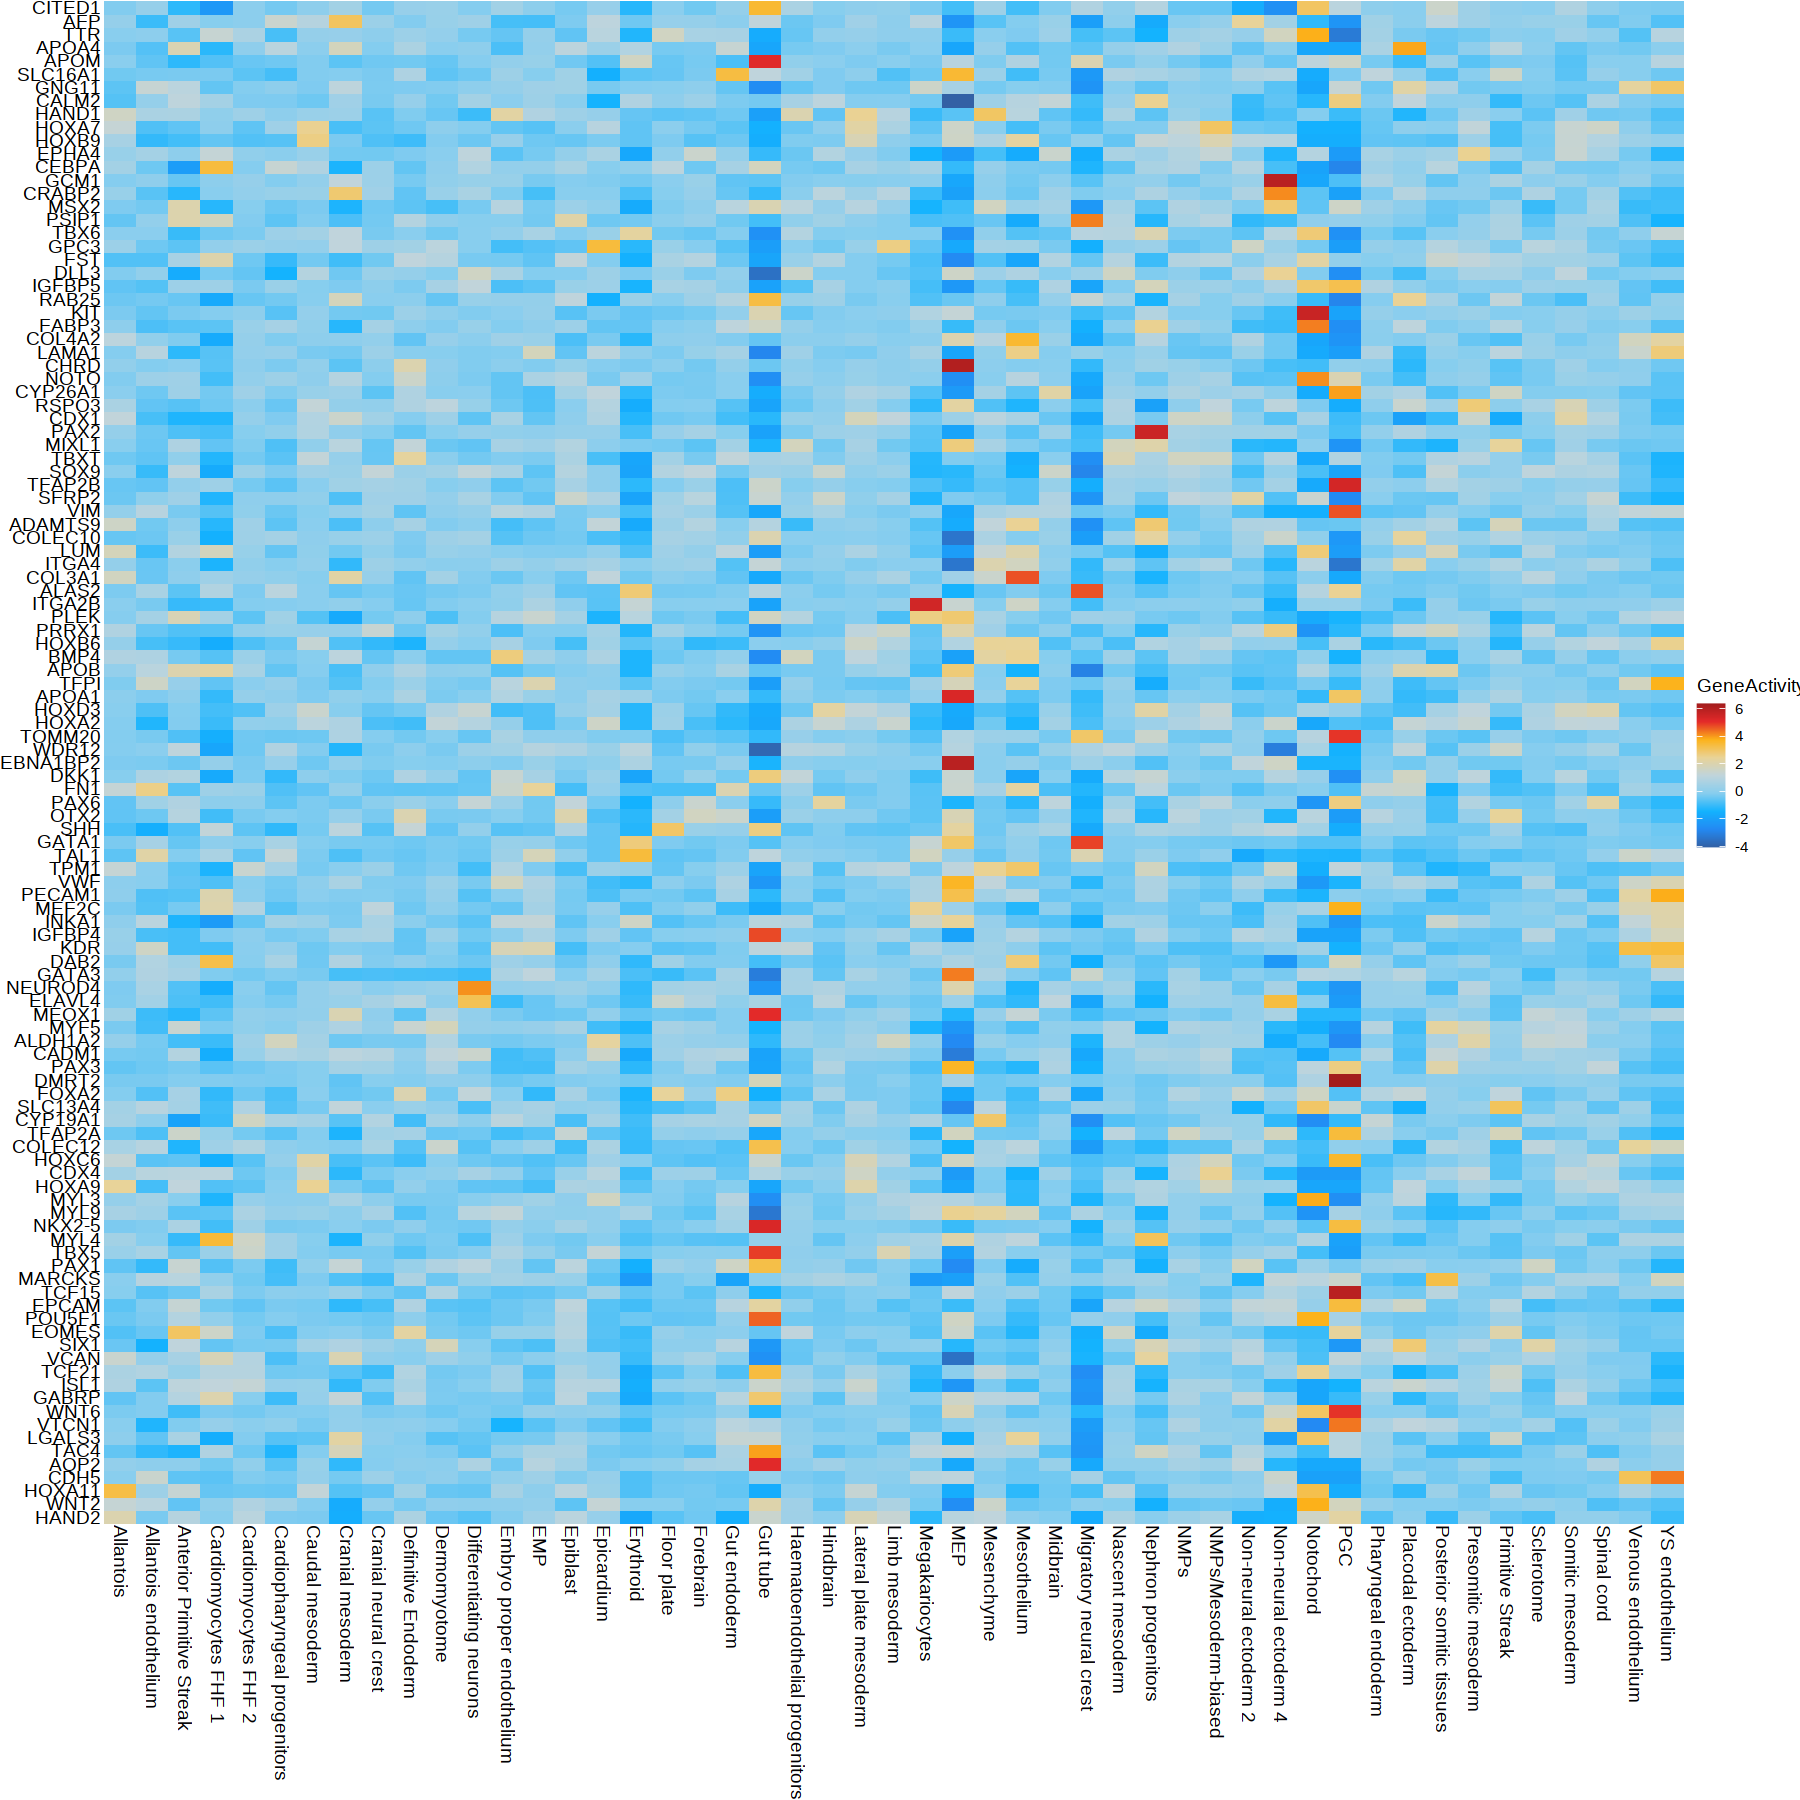

In [89]:
options(repr.plot.width=15, repr.plot.height=15)
ggplot(test, aes(celltype, gene, fill=GeneAccessibility)) + 
    geom_tile() + 
    #scale_fill_gradient2(low='blue', high='red') + 
    scale_fill_gradientn(colors = paletteContinuous(), name='GeneActivity') + 
    theme_void() + 
    theme(axis.text.x=element_text(angle=-90, hjust=0, vjust=0.5),
         axis.text.y=element_text( hjust=1, vjust=0.5))

In [63]:
rowVars(counts.minmax)

[1] 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1
 [38] 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1
 [75] 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1
[112] 1 1 1 1

In [64]:
library(ComplexHeatmap)

Loading required package: grid


Attaching package: ‘grid’


The following object is masked from ‘package:Biostrings’:

    pattern


ComplexHeatmap version 2.10.0
Bioconductor page: http://bioconductor.org/packages/ComplexHeatmap/
Github page: https://github.com/jokergoo/ComplexHeatmap
Documentation: http://jokergoo.github.io/ComplexHeatmap-reference

If you use it in published research, please cite:
Gu, Z. Complex heatmaps reveal patterns and correlations in multidimensional 
  genomic data. Bioinformatics 2016.

The new InteractiveComplexHeatmap package can directly export static 
complex heatmaps into an interactive Shiny app with zero effort. Have a try!

This message can be suppressed by:
  suppressPackageStartupMessages(library(ComplexHeatmap))




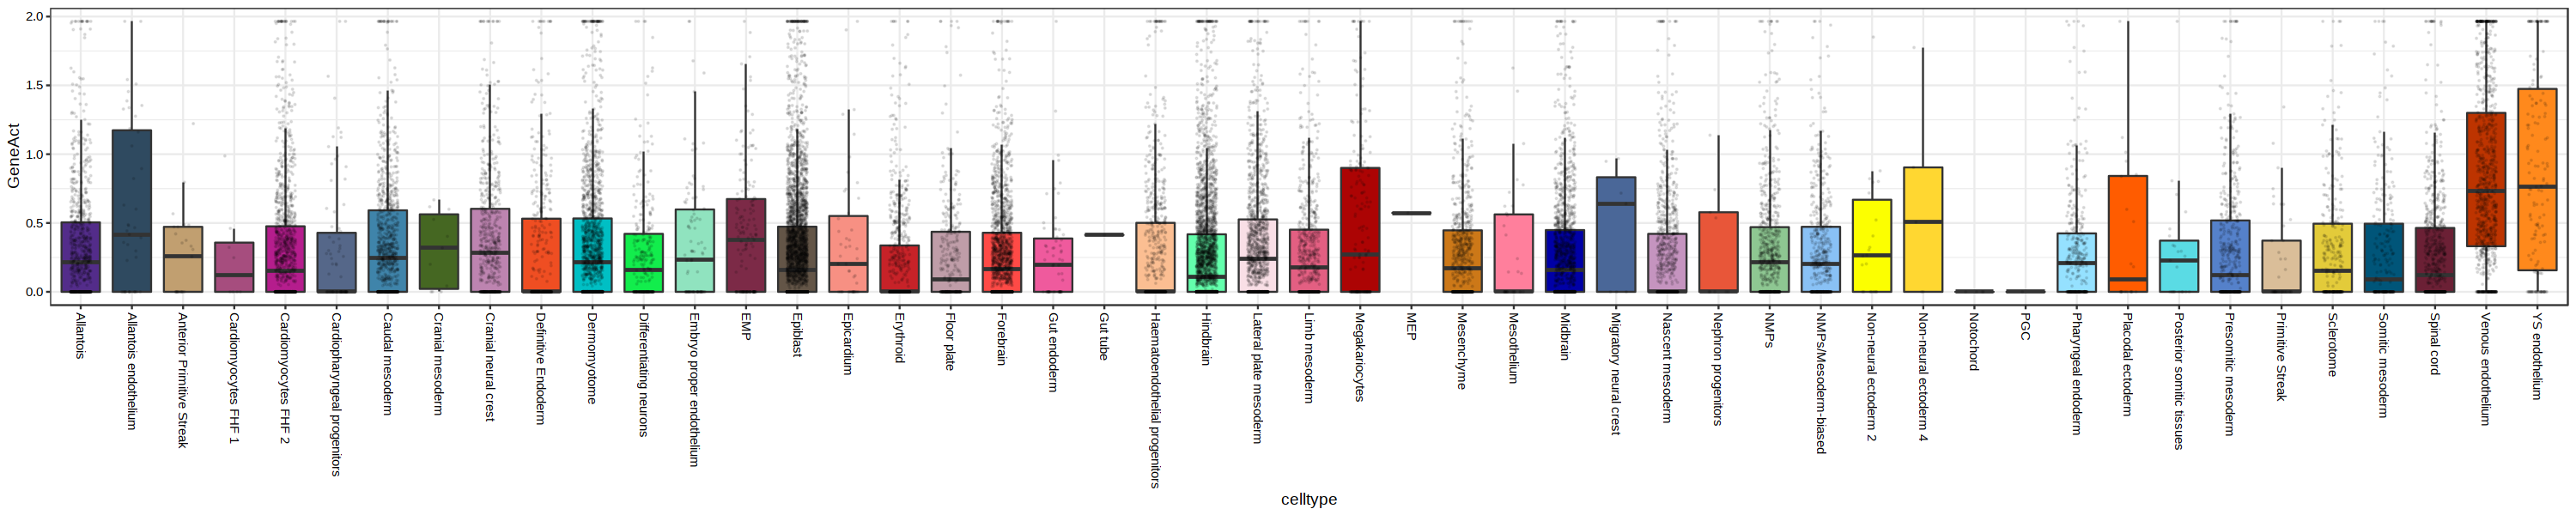

In [6]:
options(repr.plot.width=25, repr.plot.height=5)

gene = 'CDH5'
tmp = data.table(celltype = genescores$predictedGroup_celltype_PeakMatrix,
                 GeneAct = as.vector(genescores[gene,]@assays@data$GeneScoreMatrix_new)) %>% setnames(c('celltype', 'GeneAct'))
tmp = tmp[, GeneAct:=ifelse(GeneAct>quantile(GeneAct, .98), quantile(GeneAct, .98), GeneAct)]

ggplot(tmp, aes(celltype, GeneAct)) + 
    geom_boxplot(outlier.shape=NA, aes(fill=celltype)) + 
    geom_point(position=position_jitter(width=0.2), size=0.1, alpha=0.1) + 
    scale_fill_manual(values = opts$celltype_colours) + 
    theme_bw() +
    theme(axis.text.x=element_text(angle=-90, hjust=0, vjust=0.5),
         axis.text=element_text(color='black'),
         legend.position='none')

In [7]:
RNA_all_markers = fread('/rds/project/rds-SDzz0CATGms/users/bt392/04_rabbit_scATAC/RNA/celltype_markers.txt.gz')[order(-logFC)]

In [8]:
head(RNA_all_markers)

gene,logFC,logCPM,F,PValue,FDR,celltype
<chr>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<chr>
ENSOCUG00000027368,10.89440,6.811598,1274.509,4.543137e-165,7.489815e-163,Megakariocytes
FYB1,10.52245,4.848526,1745.411,2.341314e-224,1.015761e-221,Megakariocytes
SERPINB10,10.35708,5.846592,2164.088,7.102448e-256,9.757580e-253,Megakariocytes
ENSOCUG00000017941,10.30655,5.908387,2158.797,8.249919e-254,8.500510e-251,Megakariocytes
PLEK,10.19323,4.537521,2171.118,1.421069e-256,2.342775e-253,Megakariocytes
ENSOCUG00000007264,10.09965,3.921319,2558.742,1.101506e-270,4.539859e-267,Megakariocytes


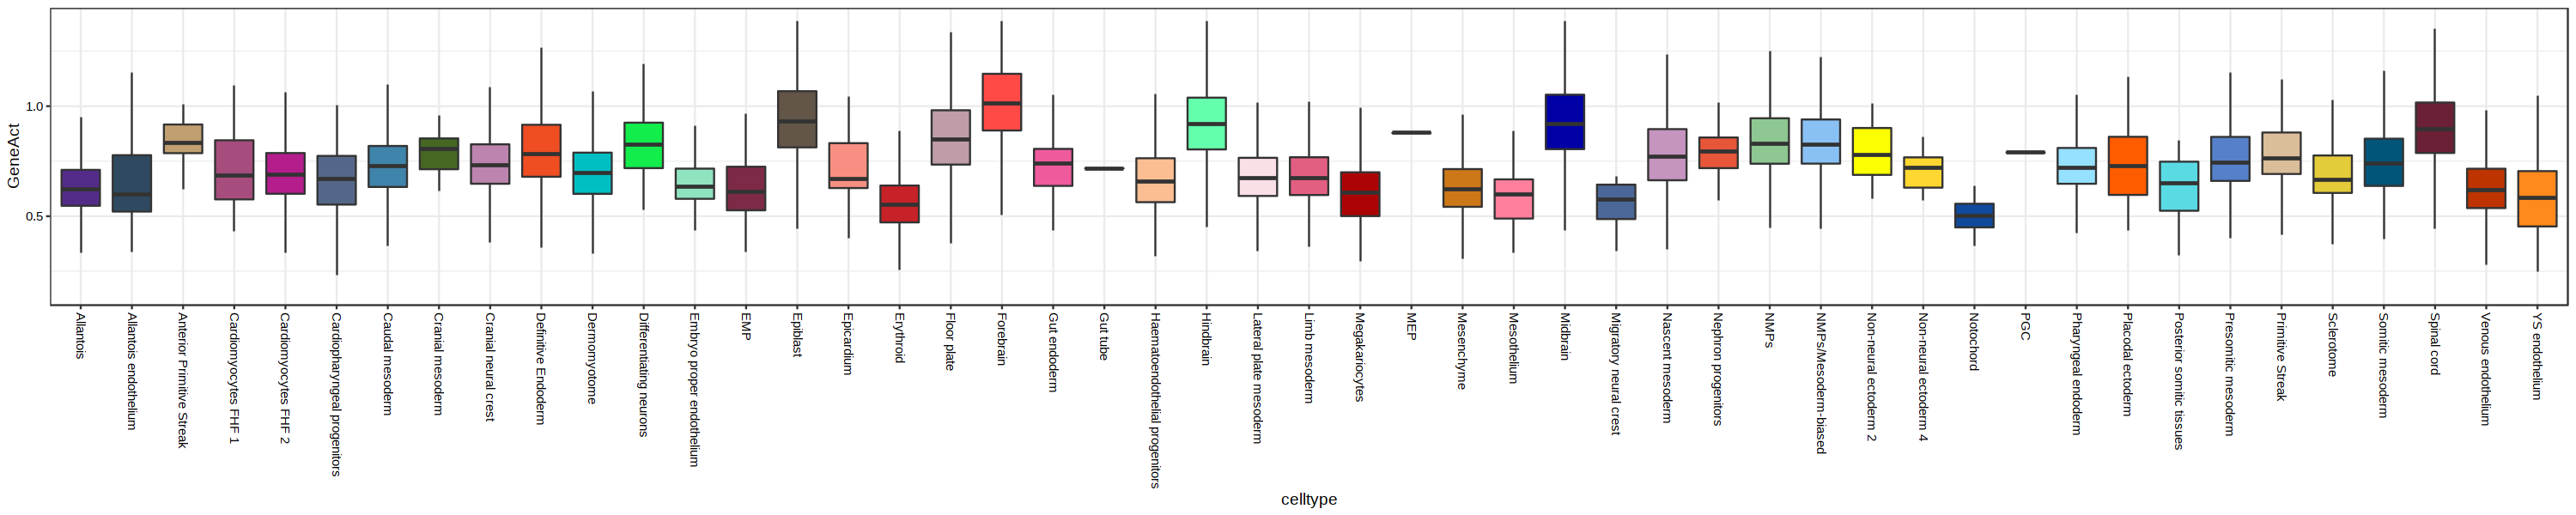

In [10]:
options(repr.plot.width=25, repr.plot.height=5)

genes = RNA_all_markers[celltype=='Forebrain' & logFC>2, gene] %>% head(80)
genes = intersect(genes, rownames(genescores))
tmp = data.table(celltype = genescores$predictedGroup_celltype_PeakMatrix,
                 GeneAct = as.vector(colMeans(genescores[genes,]@assays@data$GeneScoreMatrix_new))) %>% setnames(c('celltype', 'GeneAct'))
tmp = tmp[, GeneAct:=ifelse(GeneAct>quantile(GeneAct, .99), quantile(GeneAct, .99), GeneAct)]

ggplot(tmp, aes(celltype, GeneAct)) + 
    geom_boxplot(outlier.shape=NA,aes(fill=celltype)) + 
   # geom_point(position=position_jitter(width=0.2), size=0.1, alpha=0.1) + 
    scale_fill_manual(values = opts$celltype_colours) + 
    theme_bw() +
    theme(axis.text.x=element_text(angle=-90, hjust=0, vjust=0.5),
         axis.text=element_text(color='black'),
         legend.position='none')

In [4]:
library(SingleCellExperiment)

In [11]:
counts = genescores@assays@data$GeneScoreMatrix_new
rownames(counts) = rowData(genescores)$name

In [12]:
vars = rowVars(counts)
names(vars) = rownames(counts)

Warning message:
“Using `bins = 30` by default. Pick better value with the argument `bins`.”
Warning message:
“Removed 2705 rows containing non-finite values (stat_bin).”
Warning message:
“Removed 2 rows containing missing values (geom_bar).”


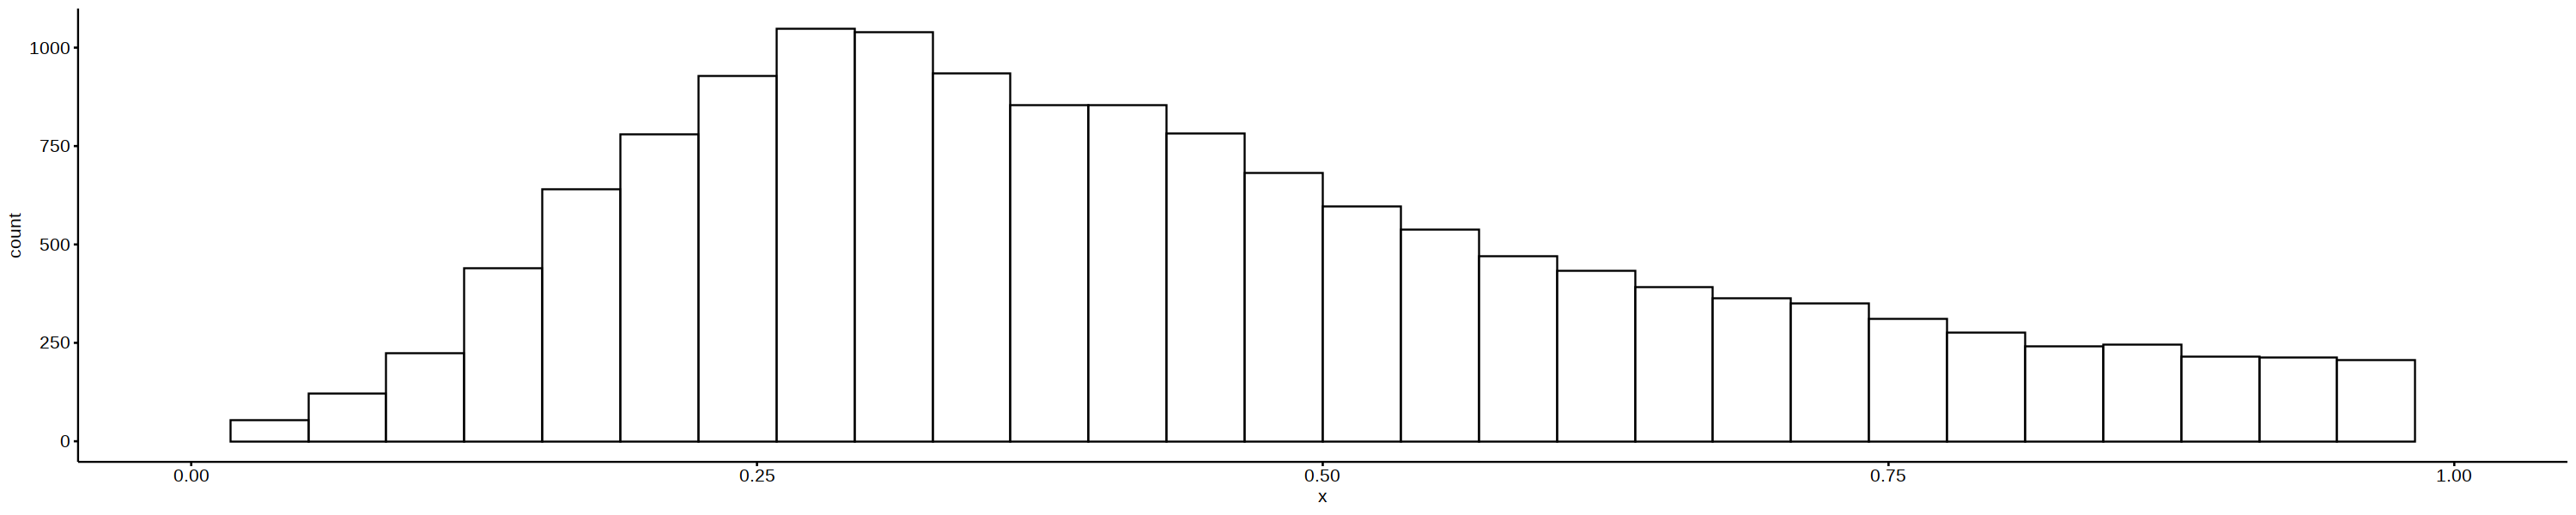

In [13]:
gghistogram(vars) + xlim(0, 1)

In [14]:
keep_genes = names(vars[vars>0.25])

In [15]:
counts = counts[keep_genes,]

In [16]:
library(Seurat)

Warning message:
“package ‘Seurat’ was built under R version 4.1.2”
Attaching SeuratObject


Attaching package: ‘Seurat’


The following object is masked from ‘package:SummarizedExperiment’:

    Assays




In [17]:
seurat  = CreateSeuratObject(counts)

Warning message:
“Non-unique features (rownames) present in the input matrix, making unique”


In [18]:
seurat

An object of class Seurat 
14053 features across 26699 samples within 1 assay 
Active assay: RNA (14053 features, 0 variable features)

In [19]:
seurat@meta.data$orig.ident = genescores$predictedGroup_celltype_PeakMatrix

In [20]:
length(unique(seurat@meta.data$orig.ident))

[1] 49

In [22]:
ident = factor(seurat@meta.data$orig.ident)
names(ident) = rownames(seurat@meta.data)

In [23]:
seurat@active.ident = ident

In [24]:
all.markers <- FindAllMarkers(object = seurat, only.pos = TRUE, min.pct = 0.25, logfc.threshold = 0.5)

Calculating cluster Allantois

Calculating cluster Allantois endothelium

Calculating cluster Anterior Primitive Streak

Calculating cluster Cardiomyocytes FHF 1

Calculating cluster Cardiomyocytes FHF 2

Calculating cluster Cardiopharyngeal progenitors

Calculating cluster Caudal mesoderm

Calculating cluster Cranial mesoderm

Calculating cluster Cranial neural crest

Calculating cluster Definitive Endoderm

Calculating cluster Dermomyotome

Calculating cluster Differentiating neurons

Calculating cluster Embryo proper endothelium

Calculating cluster EMP

Calculating cluster Epiblast

Calculating cluster Epicardium

Calculating cluster Erythroid

Calculating cluster Floor plate

Calculating cluster Forebrain

Calculating cluster Gut endoderm

Calculating cluster Gut tube

Calculating cluster Haematoendothelial progenitors

Calculating cluster Hindbrain

Calculating cluster Lateral plate mesoderm

Calculating cluster Limb mesoderm

Calculating cluster Megakariocytes

Calculating clust

In [26]:
getwd()

[1] "/rds/project/rds-SDzz0CATGms/users/bt392/04_rabbit_scATAC/ArchR"

In [27]:
fwrite(all.markers, '/rds/project/rds-SDzz0CATGms/users/bt392/04_rabbit_scATAC/ArchR/Embryo_proper/celltype_markers_atac.txt.gz')

### Load GeneActivity marker genes

In [90]:
# Load count data
genescores = readRDS(file.path(io$basedir, 'ArchR/Embryo_proper/GeneScoreMatrix_new.rds'))
counts = genescores@assays@data$GeneScoreMatrix_new
rownames(counts) = rowData(genescores)$name
vars = rowVars(counts)
names(vars) = rownames(counts)
keep_genes = names(vars[vars>0.25])
counts = counts[keep_genes,]

In [91]:
# load markers
all.markers = fread('/rds/project/rds-SDzz0CATGms/users/bt392/04_rabbit_scATAC/ArchR/Embryo_proper/celltype_markers_atac.txt.gz')

setDT(all.markers)[,head(.SD, 2), by='cluster'][cluster=='Erythroid']

cluster,p_val,avg_log2FC,pct.1,pct.2,p_val_adj,gene
<chr>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<chr>
Erythroid,0,20.34805,0.971,0.396,0,ENSOCUG00000039498
Erythroid,0,12.18178,0.978,0.634,0,ENSOCUG00000039609


In [92]:
length(unique(all.markers$gene))

[1] 9244

In [93]:
counts[1:10, 1:10]

   [[ suppressing 10 column names ‘rabbit_BGRGP1#ATCCTCGTCCGAATTG-1’, ‘rabbit_BGRGP1#CTTGCCATCTGAGTAC-1’, ‘rabbit_BGRGP1#AACAGTCTCCGATGCG-1’ ... ]]



10 x 10 sparse Matrix of class "dgCMatrix"
                                                                              
WDR31              0.324 0.604 0.887 0.255 .     1.122 0.127 0.645 0.786 0.831
PRPF4              0.153 1.622 0.345 0.297 0.612 0.658 0.064 .     0.357 0.978
CDC26              0.188 1.522 0.184 0.192 0.754 0.194 .     .     0.439 1.174
SLC31A1            .     0.253 0.083 0.170 .     0.218 .     .     .     .    
FKBP15             0.213 0.816 0.067 1.079 0.640 0.251 0.114 0.334 0.124 0.321
SLC31A2            0.206 0.835 0.335 0.639 0.342 0.101 0.182 0.714 0.061 0.821
ZFP37              .     0.101 .     0.534 0.699 0.430 0.187 0.779 0.611 0.659
ENSOCUG00000026544 0.149 0.165 0.468 .     .     0.165 0.144 0.199 0.475 0.289
SLC46A2            0.538 0.049 0.209 1.297 0.198 0.055 0.959 0.207 0.834 0.317
SNX30              0.051 0.133 0.518 0.398 0.834 0.326 0.202 0.323 .     0.433

In [94]:
library(scran)

In [95]:
BPPARAM <- BiocParallel::bpparam()
BPPARAM$workers = 16

In [96]:
library(SingleCellExperiment)

In [97]:
rownames(counts) = as.character(rownames(counts))

In [98]:
sce <- SingleCellExperiment(list(counts=counts))

In [99]:
sce

class: SingleCellExperiment 
dim: 14053 26699 
metadata(0):
assays(1): counts
rownames(14053): WDR31 PRPF4 ... ENSOCUG00000029751 GPR101
rowData names(0):
colnames(26699): rabbit_BGRGP1#ATCCTCGTCCGAATTG-1
  rabbit_BGRGP1#CTTGCCATCTGAGTAC-1 ... rabbit_BGRGP4#CCTTGCATCATCATGG-1
  rabbit_BGRGP4#TAAGTGCGTGTTTCTT-1
colData names(0):
reducedDimNames(0):
mainExpName: NULL
altExpNames(0):

In [100]:
colData(sce) = colData(genescores)

In [101]:
# excl celltypes with too few cells
cell_nr = as.data.table(colData(sce)) %>% .[,N:=.N, by='predictedGroup_celltype_PeakMatrix'] %>% unique(by='predictedGroup_celltype_PeakMatrix') %>% .[,c('predictedGroup_celltype_PeakMatrix', 'N')]
ct_keep = cell_nr[N>20, predictedGroup_celltype_PeakMatrix]

In [102]:
sce_pseudobulk <- aggregateAcrossCells(sce, id=sce$predictedGroup_celltype_PeakMatrix, statistics = 'mean', BPPARAM = BPPARAM)

In [103]:
sce_pseudobulk

class: SingleCellExperiment 
dim: 14053 49 
metadata(0):
assays(1): counts
rownames(14053): WDR31 PRPF4 ... ENSOCUG00000029751 GPR101
rowData names(0):
colnames(49): Allantois Allantois endothelium ... Venous endothelium YS
  endothelium
colData names(27): DoubletEnrichment DoubletScore ... ids ncells
reducedDimNames(0):
mainExpName: NULL
altExpNames(0):

In [104]:
counts_pseudobulk = counts(sce_pseudobulk)

In [105]:
top_markers = unique(setDT(all.markers)[,head(.SD, 1), by='cluster'][,gene])

In [106]:
length(top_markers)

[1] 42

In [107]:
counts_pseudobulk_markers = counts_pseudobulk[top_markers,]

In [108]:
library(ComplexHeatmap)

In [120]:
top_markers = unique(setDT(all.markers)[,head(.SD, 5), by='cluster']) %>%
    .[cluster %in% ct_keep]

In [111]:
counts_pseudobulk_markers = counts_pseudobulk[top_markers$gene,top_markers$cluster]
# minmax normalise
#counts_pseudobulk_markers = apply(counts_pseudobulk_markers, 2, minmax)

In [112]:
test = as.data.table(t(scale(t(counts_pseudobulk_markers))), keep.rownames=T) %>%
                        setnames('rn', 'gene') %>%
                        melt(id.vars = 'gene', variable.name='celltype', value.name='GeneAccessibility') %>%
                        .[,capped:=ifelse(GeneAccessibility<=-2, -2, 
                                          ifelse(GeneAccessibility>=2, 2, GeneAccessibility))] %>%
                       .[,`:=`(gene = factor(gene, levels = unique(top_markers$gene)),
                               celltype = factor(celltype, levels = unique(top_markers$cluster)))]

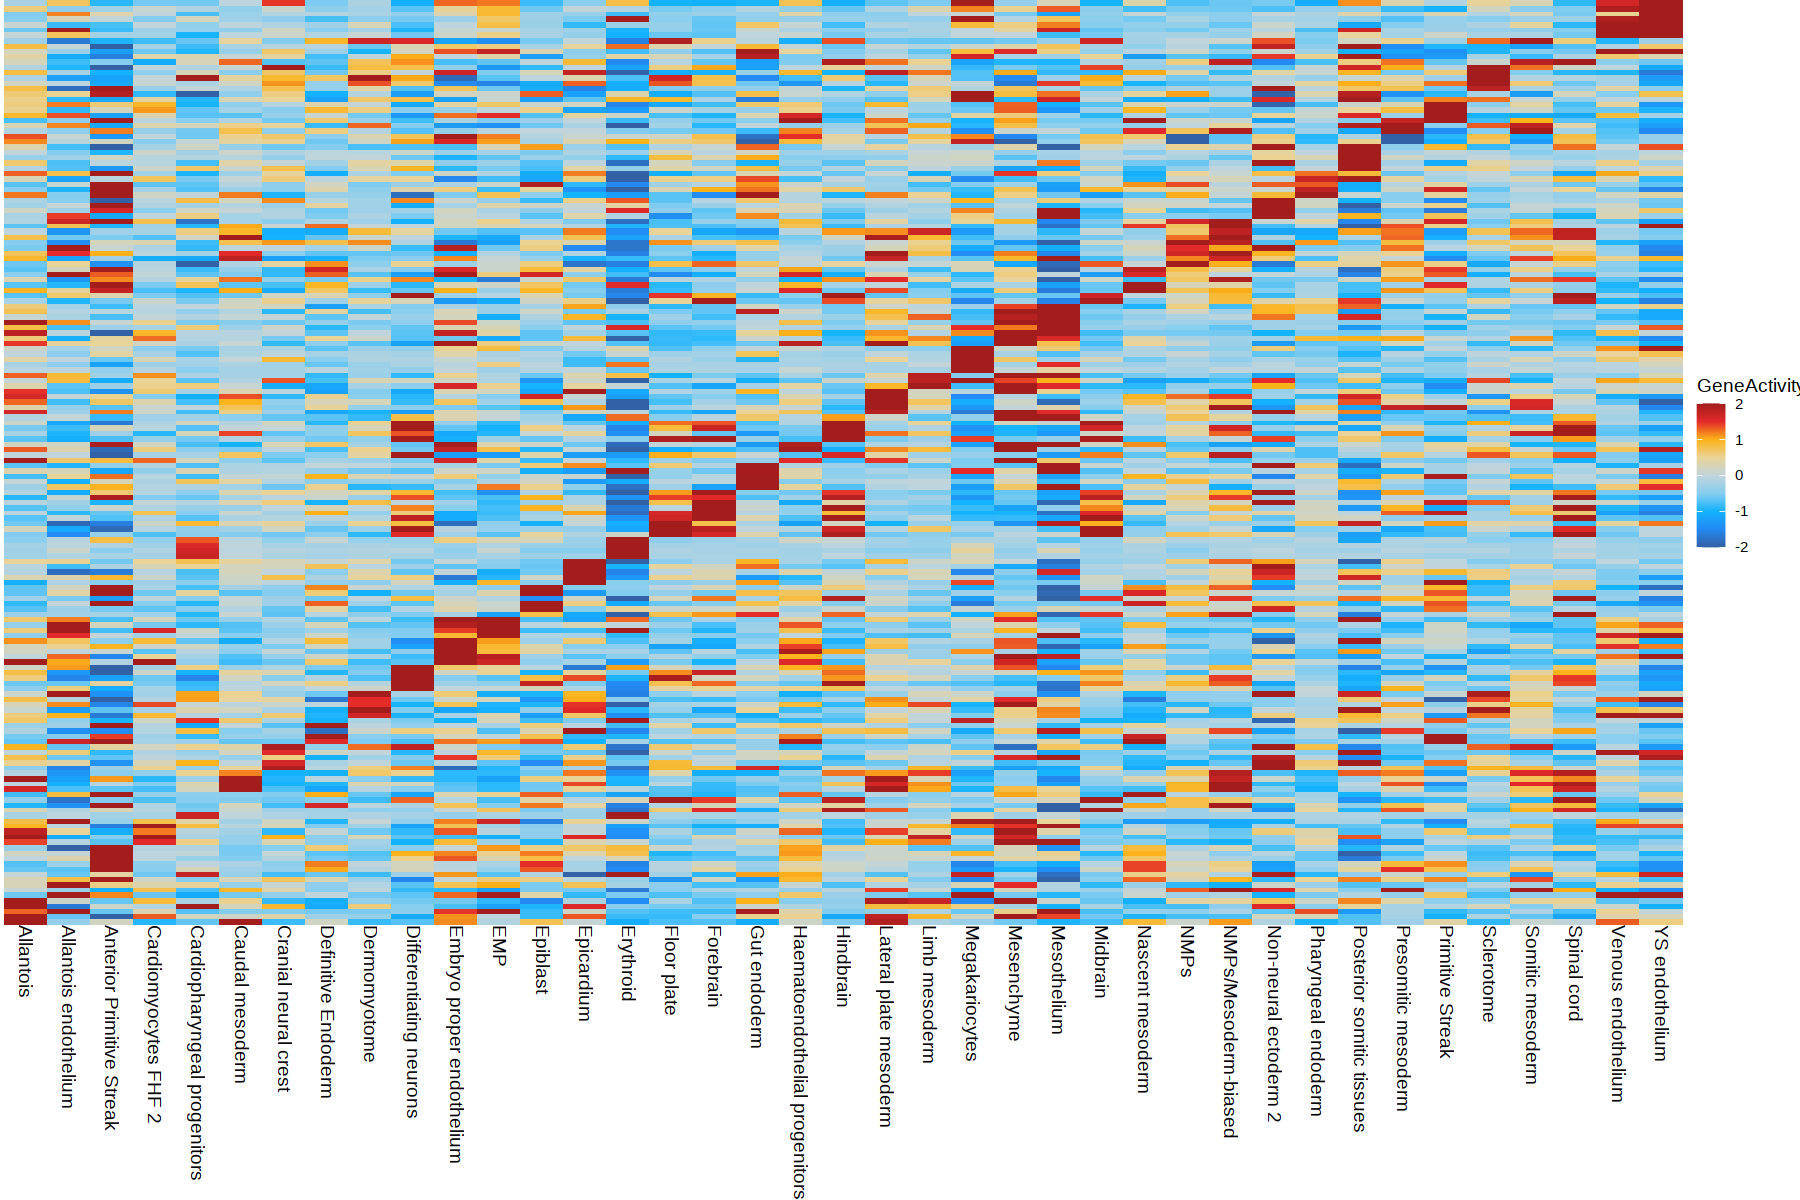

In [113]:
options(repr.plot.width=15, repr.plot.height=10)
ggplot(test, aes(celltype, gene, fill=capped)) + 
    geom_tile() + 
#    scale_fill_gradient2(low='blue', high='red') + 
    scale_fill_gradientn(colors = paletteContinuous(), name='GeneActivity') + 
    #scale_fill_viridis() + 
    theme_void() + 
    theme(axis.text.x=element_text(angle=-90, hjust=0, vjust=0.5),
         axis.text.y=element_blank())

## RNA Markers

In [154]:
# load markers
all.markers = fread('/rds/project/rds-SDzz0CATGms/users/bt392/04_rabbit_scATAC/RNA/celltype_markers.txt.gz')

top_markers = unique(setDT(all.markers)[,head(.SD, 15), by='celltype']%>%
    .[celltype %in% ct_keep] %>%
     .[,gene])
top_markers = top_markers[top_markers %in% rownames(counts_pseudobulk)] 

In [155]:
counts_pseudobulk_markers = counts_pseudobulk[top_markers,ct_keep]

In [156]:
library(ComplexHeatmap)

In [157]:
test = as.data.table(t(scale(t(counts_pseudobulk_markers))), keep.rownames=T) %>%
                        setnames('rn', 'gene') %>%
                        melt(id.vars = 'gene', variable.name='celltype', value.name='GeneAccessibility') %>%
                        .[,capped:=ifelse(GeneAccessibility<=-2, -2, 
                                          ifelse(GeneAccessibility>=2, 2, GeneAccessibility))] %>%
                       .[,`:=`(gene = factor(gene, levels = unique(top_markers)),
                               celltype = factor(celltype, levels = ct_keep[order(ct_keep)]))]

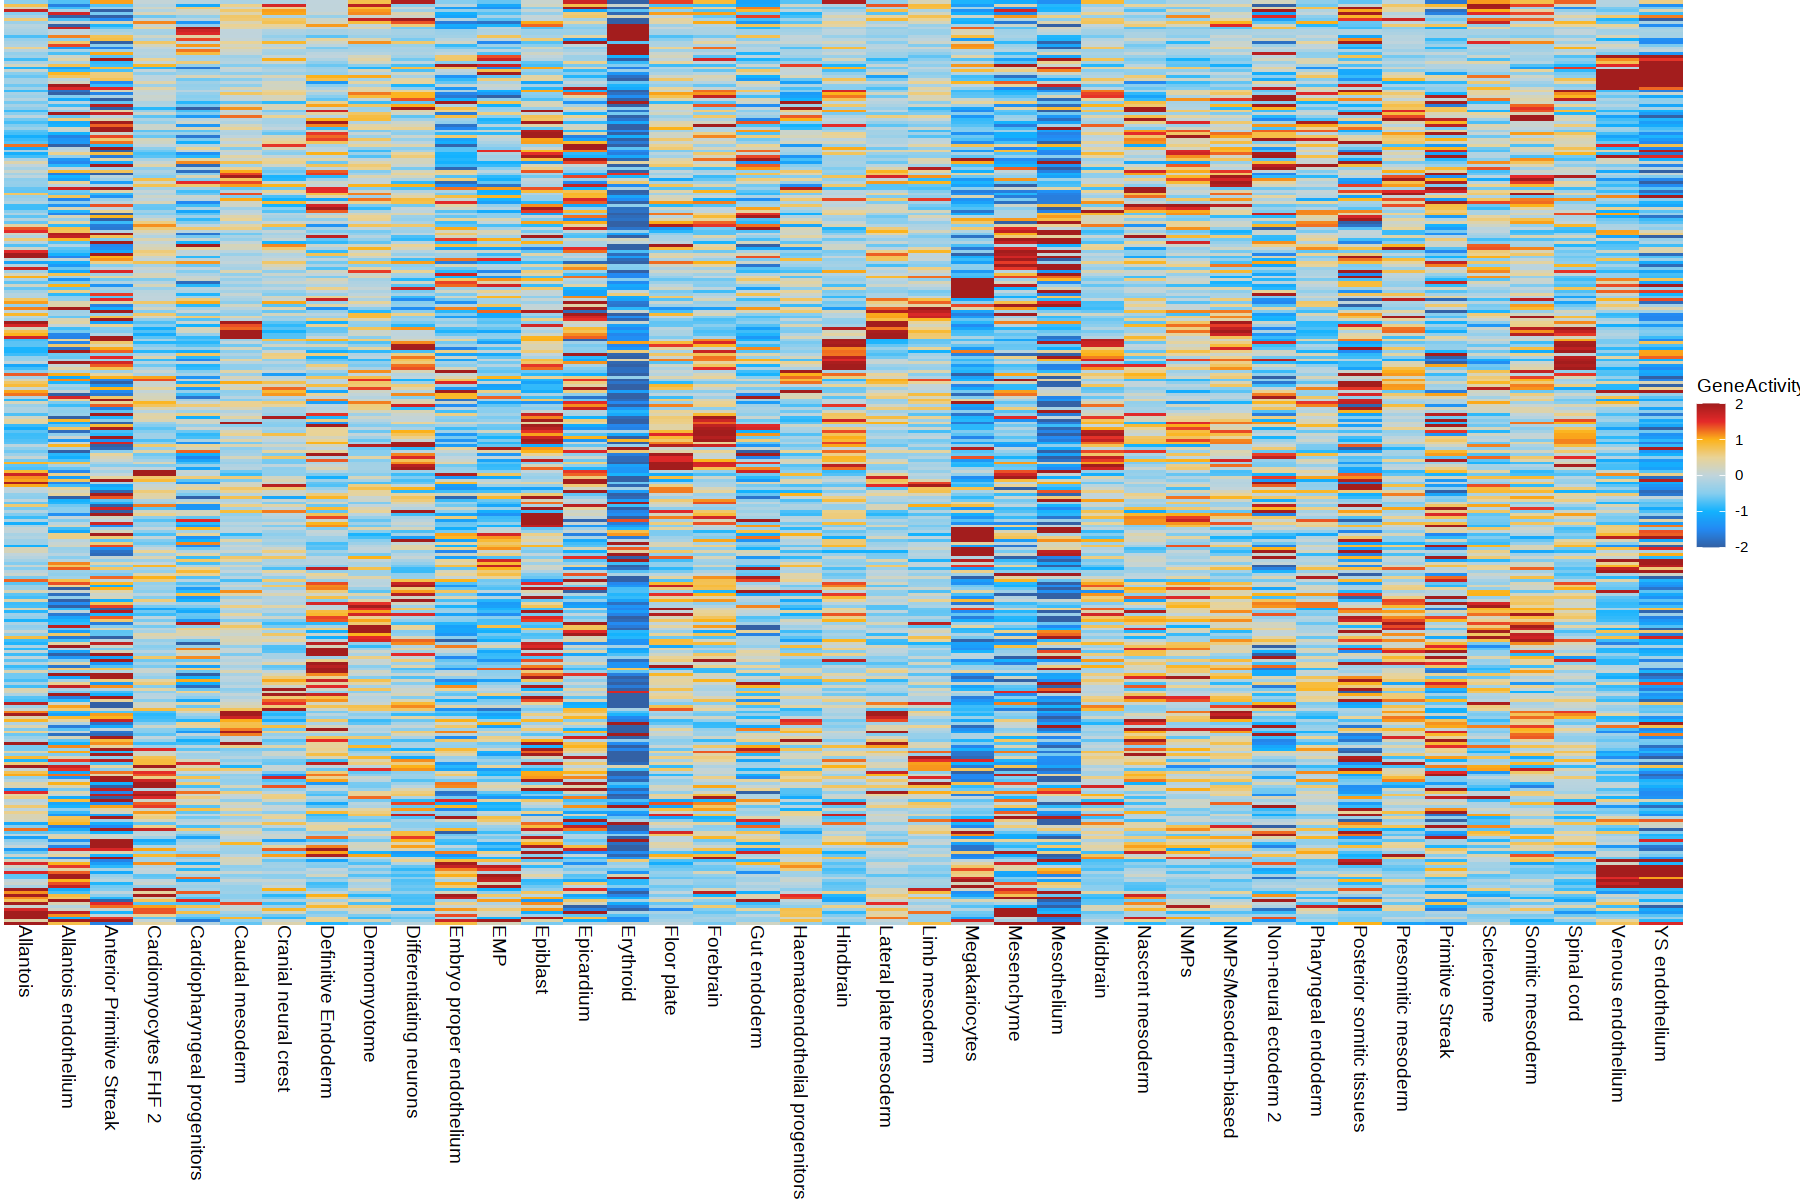

In [158]:
options(repr.plot.width=15, repr.plot.height=10)
ggplot(test, aes(celltype, gene, fill=capped)) + 
    geom_tile() + 
#    scale_fill_gradient2(low='blue', high='red') + 
    scale_fill_gradientn(colors = paletteContinuous(), name='GeneActivity') + 
    #scale_fill_viridis() + 
    theme_void() + 
    theme(axis.text.x=element_text(angle=-90, hjust=0, vjust=0.5),
         axis.text.y=element_blank())

In [159]:
head(all.markers)

gene,logFC,logCPM,F,PValue,FDR,celltype
<chr>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<chr>
VCAM1,3.883440,3.804130,110.03196,1.822596e-24,3.004731e-21,Allantois
ENSOCUG00000026099,3.516147,7.135751,83.04219,4.070050e-19,4.193678e-16,Allantois
ENSOCUG00000016623,3.450787,3.896460,60.51383,1.841065e-14,8.926999e-12,Allantois
HOXA13,3.442119,3.709014,118.07247,4.685392e-26,1.287390e-22,Allantois
TBX20,3.269618,3.387785,70.35334,1.605591e-16,1.102908e-13,Allantois
WNT2,3.115967,5.486844,63.74895,3.743100e-15,2.203884e-12,Allantois


In [180]:
counts_pseudobulk = counts_pseudobulk[,ct_keep]

In [181]:
# mean per celltype's marker
mean_markers = function(x, logFC_i=0, head_i=80, scale=TRUE){
        markers_tmp = all.markers[celltype==x] %>% 
            .[logFC>logFC_i] %>% 
            .[order(-logFC), gene] %>% head(head_i)
        markers_tmp = intersect(markers_tmp, rownames(counts_pseudobulk))

        if(length(markers_tmp)>1){
            atac.tmp =  data.table(celltype = colnames(counts_pseudobulk), celltype_markers = x, atac_counts = minmax(colMeans(counts_pseudobulk[markers_tmp,])))
        }
        
    
        return(atac.tmp)
}

In [184]:
    tmp = lapply(ct_keep, mean_markers, logFC_i = 2.5, head_i = 1000, scale = TRUE) %>% rbindlist()

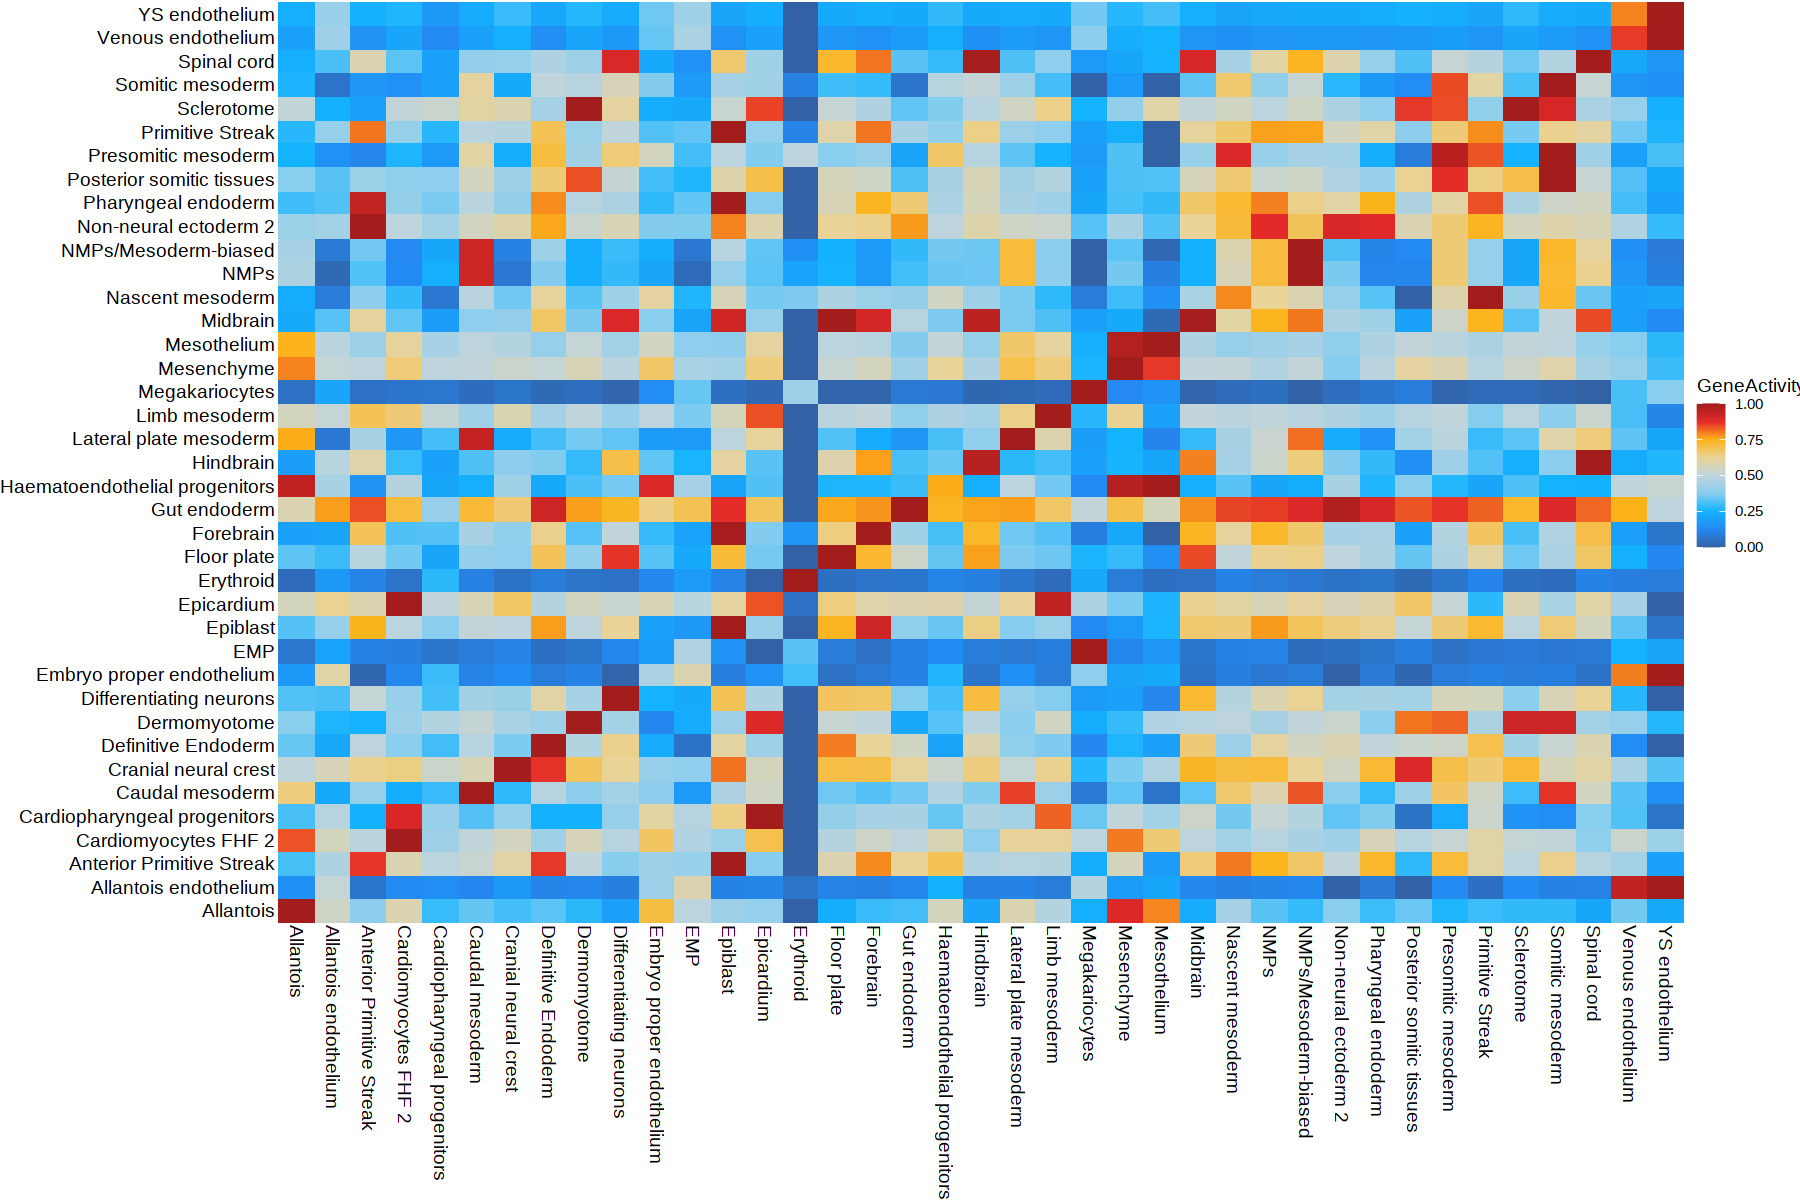

In [185]:
ggplot(tmp, aes(celltype, celltype_markers, fill=atac_counts)) + 
    geom_tile() + 
    scale_fill_gradientn(colors = paletteContinuous(), name='GeneActivity') + 
    theme_void() + 
    theme(axis.text.x=element_text(angle=-90, hjust=0, vjust=0.5),
         axis.text.y=element_text( hjust=1, vjust=0.5))

In [167]:
mean_markers('Allantois')

celltype,atac_counts
<chr>,<dbl>
Allantois,1.1476859
Allantois endothelium,0.9043608
Anterior Primitive Streak,0.7641851
Cardiomyocytes FHF 1,0.8377071
Cardiomyocytes FHF 2,0.9408886
Cardiopharyngeal progenitors,0.8199925
Caudal mesoderm,0.8373833
Cranial mesoderm,0.8046974
Cranial neural crest,0.8492218


# Motif enrichment

In [6]:
meta = as.data.table(ArchRProject@cellColData)
cell_nr = as.data.table(meta) %>% .[,N:=.N, by='predictedGroup_celltype_PeakMatrix'] %>% unique(by='predictedGroup_celltype_PeakMatrix') %>% .[,c('predictedGroup_celltype_PeakMatrix', 'N')]
ct_keep = cell_nr[N>40, predictedGroup_celltype_PeakMatrix]

In [7]:
ArchRProject = ArchRProject[ArchRProject$predictedGroup_celltype_PeakMatrix %in% ct_keep,]

In [8]:
addArchRThreads(1)
addArchRVerbose(verbose = TRUE)

Setting default number of Parallel threads to 1.

Setting addArchRVerbose = TRUE



In [ ]:
markersPeaks <- getMarkerFeatures(
    ArchRProj = ArchRProject, 
    useMatrix = "PeakMatrix", 
    groupBy = "predictedGroup_celltype_PeakMatrix",
  bias = c("TSSEnrichment", "log10(nFrags)"),
  testMethod = "wilcoxon",
    verbose=F
)

ArchR logging to : ArchRLogs/ArchR-getMarkerFeatures-239ad750bce55-Date-2022-12-13_Time-20-46-37.log
If there is an issue, please report to github with logFile!

MatrixClass = Sparse.Integer.Matrix

Pairwise Test Allantois : Seqnames chr1

Pairwise Test Allantois : Seqnames chr10

Pairwise Test Allantois : Seqnames chr11

Pairwise Test Allantois : Seqnames chr12

Pairwise Test Allantois : Seqnames chr13

Pairwise Test Allantois : Seqnames chr14

Pairwise Test Allantois : Seqnames chr15

Pairwise Test Allantois : Seqnames chr16

Pairwise Test Allantois : Seqnames chr17

Pairwise Test Allantois : Seqnames chr18

Pairwise Test Allantois : Seqnames chr19

Pairwise Test Allantois : Seqnames chr2

Pairwise Test Allantois : Seqnames chr20

Pairwise Test Allantois : Seqnames chr21

Pairwise Test Allantois : Seqnames chr3

Pairwise Test Allantois : Seqnames chr4

Pairwise Test Allantois : Seqnames chr5

Pairwise Test Allantois : Seqnames chr6

Pairwise Test Allantois : Seqnames chr7

Pairwise T

In [ ]:
saveRDS(markersPeaks, sprintf('%s/markersPeaks.rds', io$plot))

In [ ]:
markersPeaks

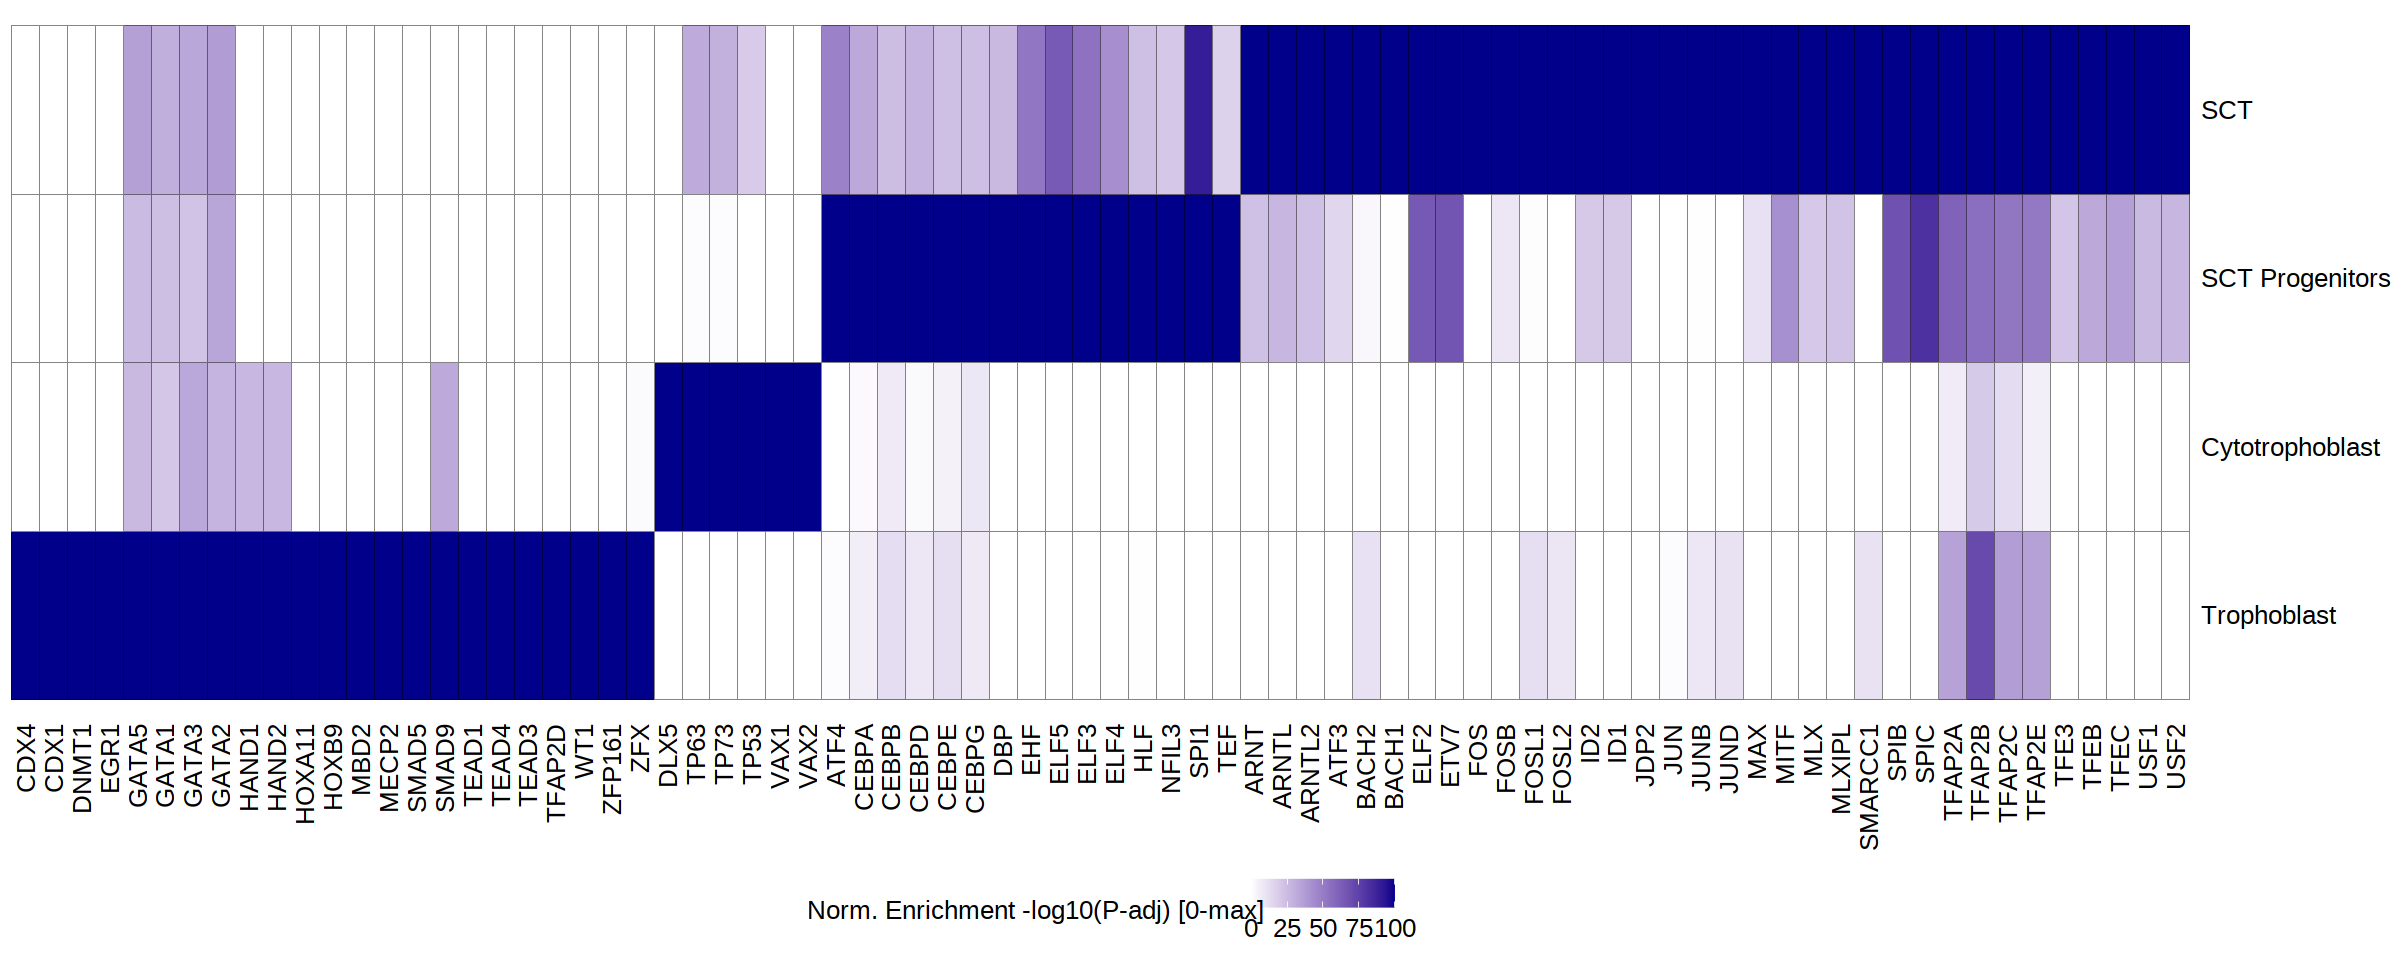

In [70]:
motifs <- peakAnnoEnrichment(
    seMarker = markersPeaks,
    ArchRProj = subset,
    peakAnnotation = "Motif",
    cutOff = "FDR <= 0.05 & Log2FC >= 0.5"
  )

In [ ]:
plot_enr_heatmap = function(enrichMotifs, ntop=25, TF_family=TRUE, TF_keep=c(NULL)) {
    heatmapEM <- plotEnrichHeatmap(enrichMotifs, n = ntop, returnMatrix = TRUE)
    
    enriched.dt = melt(as.data.table(heatmapEM, keep.rownames=T) %>% setnames('rn', 'TF'), id.vars = c("TF")) %>%
        .[order(-value)] 
    keep_tfs = enriched.dt[, head(.SD, ntop),  by=variable]$TF
    enriched.dt = enriched.dt[TF %in% keep_tfs] %>% .[order( -value)] %>% 
        .[,TF:=strsplit(TF, '_') %>% map_chr(1)] %>%
        .[,TF_family:=sub("[0-9].*$", "", TF)] %>%
        .[,TF_family:=ifelse(TF_family=='TFAP', TF, TF_family)] %>% # restory TFAP bc TFAP2D behaves different
        .[,TF_family:=ifelse(TF_family=='E', 'E2F', TF_family)] %>% # E2F cut off too short
         .[order(-value, variable, TF_family)] %>% 
         .[,TF:=factor(TF, levels=rev(unique(TF)))]
    
    if(!is.null(TF_keep)){
        enriched.dt = enriched.dt[TF %in% TF_keep]
    }
    
    p = ggplot(enriched.dt, aes(TF, variable, fill=value)) + 
    geom_tile(col='black') + 
    scale_fill_gradient2(low='grey80', high='darkblue', name='Norm. Enrichment -log10(P-adj) [0-max]', position='bottom') + 
    scale_y_discrete(position = "right") +
    guides(fill = guide_legend(title.position = "top")) +
    theme_classic() + theme(text = element_text(size = 15, colour='black'), 
                            axis.text.y = element_text(hjust=1, size = 15, colour='black'),
                            axis.text.x = element_text(size = 15, colour='black', angle=90, hjust=1, vjust=0.5),
                            axis.line.x = element_blank(),
                            axis.line.y = element_blank(),
                            axis.ticks = element_blank(), 
                            axis.title = element_blank(), 
                            strip.text.y = element_text(angle = 0, size=10),
                            legend.text = element_text(size=15),
                            legend.position='bottom')

    if(TF_family==TRUE){
    enriched.dt = enriched.dt %>%
        unique(by=c('TF_family', 'variable')) %>% 
         .[,TF_family:=factor(TF_family, levels=unique(TF_family))]
        
    p = ggplot(enriched.dt, aes(TF_family, variable, fill=value)) + 
        geom_tile(col='black') + 
        #viridis::scale_fill_viridis(name='Norm. Enrichment -log10(P-adj) [0-max]') + 
        scale_fill_gradient2(low='grey80', high='darkblue', name='Norm. Enrichment -log10(P-adj) [0-max]') + 
        scale_y_discrete(position = "right") +
        theme_classic() + theme(text = element_text(size = 15, colour='black'), 
                            axis.text.y = element_text(hjust=1, size = 15, colour='black'),
                            axis.text.x = element_text(size = 15, colour='black', angle=90, hjust=1, vjust=0.5),
                            axis.line.x = element_blank(),
                            axis.line.y = element_blank(),
                            axis.ticks = element_blank(), 
                            axis.title = element_blank(), 
                            strip.text.y = element_text(angle = 0, size=10),
                            legend.text = element_text(size=15),
                               legend.position='bottom')
        
    }


    return(p)
}

In [ ]:
options(repr.plot.width=20, repr.plot.height=8)
p = plot_enr_heatmap(motifs, ntop = 1000, TF_family=F)
p